<a href="https://colab.research.google.com/github/220109cse-creat/220109svm/blob/main/220109_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("all libraries imported")

all libraries imported


In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print("Dataset Loaded: Breast Cancer Wisconsin")
print(f"   Shape       : {df.shape}")
print(f"   Classes     : {data.target_names.tolist()}")
print(f"   Class counts:\n{df['target'].value_counts().rename({0: 'Malignant', 1: 'Benign'})}")
print("\nFirst 5 rows:")
print(df.head())

Dataset Loaded: Breast Cancer Wisconsin
   Shape       : (569, 31)
   Classes     : ['malignant', 'benign']
   Class counts:
target
Benign       357
Malignant    212
Name: count, dtype: int64

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414 

In [3]:
print("\n missing values")
print(df.isnull().sum().sum(), "total missing values found.")
df.fillna(df.median(), inplace=True)
print("missing values handled (median imputation if any).")
print("\n categorical encoding: No categorical features (already numeric).")

X = df.drop('target', axis=1)
y = df['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full
)

print(f"\n data split:")
print(f"train: {X_train.shape[0]} samples")
print(f"validation: {X_val.shape[0]} samples")
print(f"test: {X_test.shape[0]} samples")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("\n using StandardScaler (zero mean, unit variance).")


 missing values
0 total missing values found.
missing values handled (median imputation if any).

 categorical encoding: No categorical features (already numeric).

 data split:
train: 397 samples
validation: 86 samples
test: 86 samples

 using StandardScaler (zero mean, unit variance).


In [4]:
svm_base = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_base.fit(X_train_scaled, y_train)

y_val_pred  = svm_base.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"\n baseline svm trained (rbf kernel, C=1, gamma='scale')")
print(f" validation Accuracy: {val_accuracy:.4f}")


 baseline svm trained (rbf kernel, C=1, gamma='scale')
 validation Accuracy: 0.9884


In [9]:
print("\n GridSearchCV for Hyperparameter Tuning")
print("   Parameters: kernel ∈ {rbf, linear, poly}, C, gamma, degree")

param_grid = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
    },
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'degree': [2, 3],
        'gamma': ['scale', 'auto']
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_params = grid_search.best_params_
best_score  = grid_search.best_score_

print(f"\n Best Parameters : {best_params}")
print(f" Best CV Accuracy : {best_score:.4f}")


best_svm = grid_search.best_estimator_
best_svm.fit(X_train_scaled, y_train)

y_test_pred      = best_svm.predict(X_test_scaled)
y_test_prob      = best_svm.predict_proba(X_test_scaled)[:, 1]


 GridSearchCV for Hyperparameter Tuning
   Parameters: kernel ∈ {rbf, linear, poly}, C, gamma, degree
Fitting 5 folds for each of 36 candidates, totalling 180 fits

 Best Parameters : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
 Best CV Accuracy : 0.9749


In [13]:
accuracy  = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall    = recall_score(y_test, y_test_pred)
f1        = f1_score(y_test, y_test_pred)
auc       = roc_auc_score(y_test, y_test_prob)

print("EVALUATION METRICS (Test Set)")
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred,
                            target_names=['Malignant', 'Benign']))


EVALUATION METRICS (Test Set)
  Accuracy  : 0.9535  (95.35%)
  Precision : 0.9808
  Recall    : 0.9444
  F1-Score  : 0.9623
  AUC-ROC   : 0.9954

Detailed Classification Report:
              precision    recall  f1-score   support

   Malignant       0.91      0.97      0.94        32
      Benign       0.98      0.94      0.96        54

    accuracy                           0.95        86
   macro avg       0.95      0.96      0.95        86
weighted avg       0.96      0.95      0.95        86



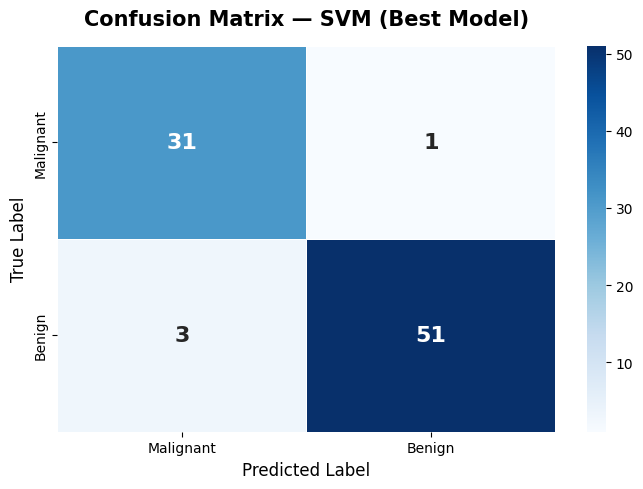

Confusion Matrix saved as 'confusion_matrix.png'


In [14]:
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign'],
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 16, "weight": "bold"}
)
ax.set_title('Confusion Matrix — SVM (Best Model)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion Matrix saved as 'confusion_matrix.png'")

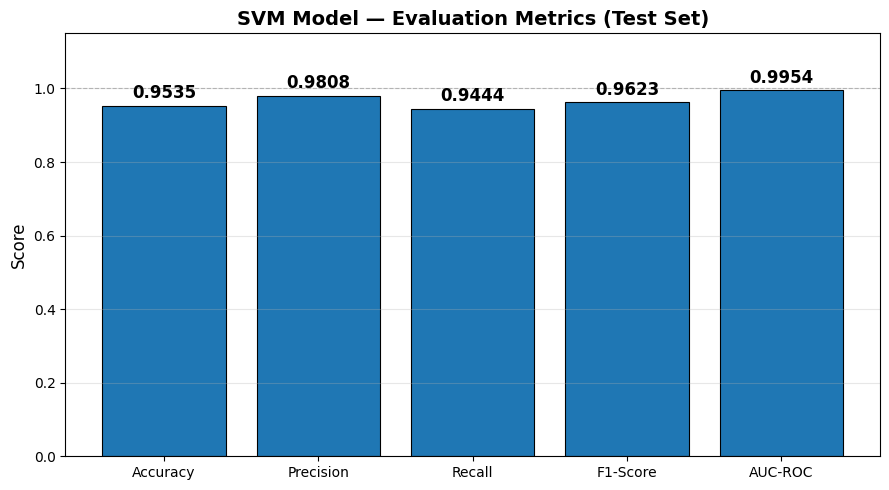

Evaluation Metrics chart saved as 'evaluation_metrics.png'


In [16]:
metrics = {
    'Accuracy' : accuracy,
    'Precision': precision,
    'Recall'   : recall,
    'F1-Score' : f1,
    'AUC-ROC'  : auc
}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics.keys(), metrics.values(), edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, metrics.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.set_ylim(0, 1.15)
ax.set_title('SVM Model — Evaluation Metrics (Test Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Evaluation Metrics chart saved as 'evaluation_metrics.png'")

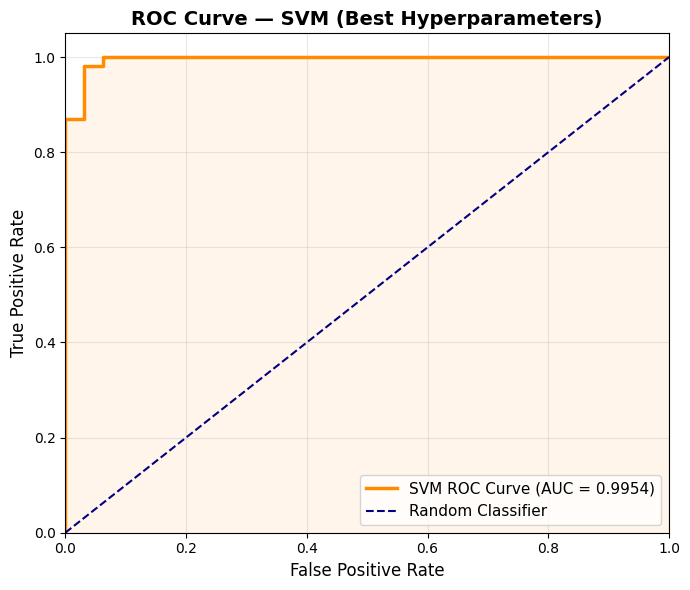

ROC Curve saved as 'roc_curve.png'


In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2.5,
        label=f'SVM ROC Curve (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — SVM (Best Hyperparameters)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC Curve saved as 'roc_curve.png'")


 Sample Predictions (20 random test samples)
 Sample # Actual Label Predicted Label Probability (Benign) Correct?
       37       Benign          Benign               1.0000         
        7    Malignant       Malignant               0.0105         
       73    Malignant       Malignant               0.0001         
       77       Benign       Malignant               0.4551         
       31       Benign          Benign               1.0000         
       51       Benign       Malignant               0.2020         
       13       Benign          Benign               0.8940         
       39       Benign          Benign               0.8749         
       71       Benign          Benign               0.8457         
       78       Benign          Benign               0.9968         
       69       Benign          Benign               0.9902         
       34    Malignant       Malignant               0.0000         
       81    Malignant       Malignant               0.00

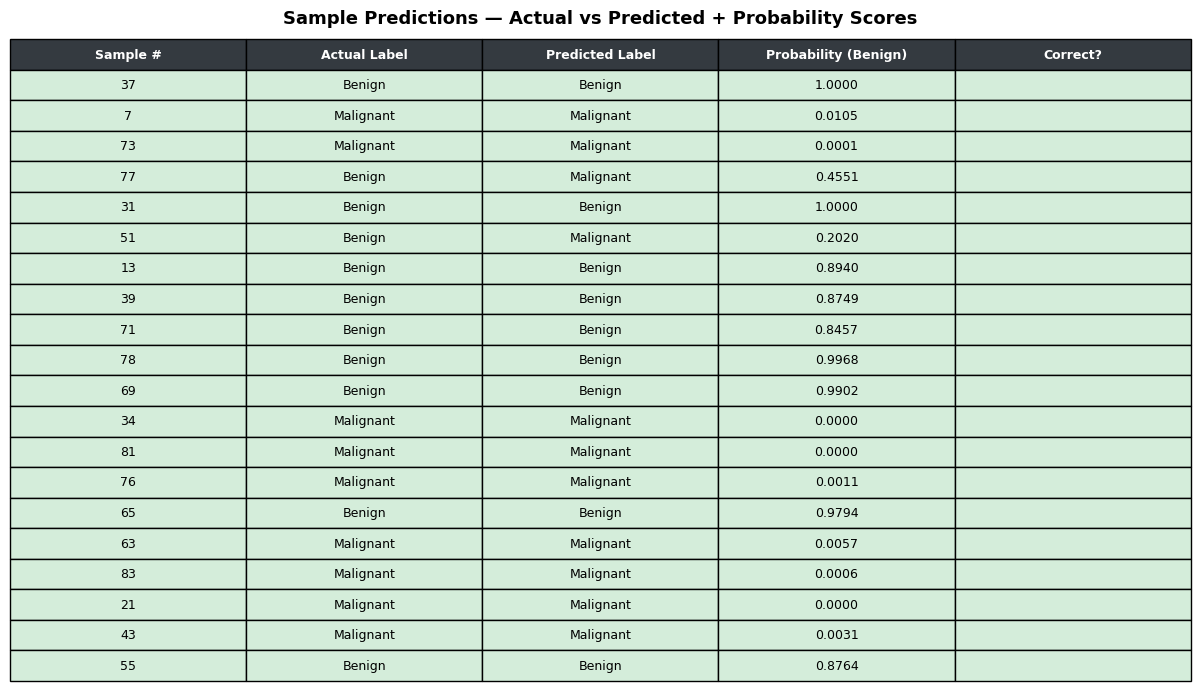

Sample Predictions table saved as 'sample_predictions.png'


In [18]:
sample_indices = np.random.choice(len(X_test_scaled), size=20, replace=False)
sample_actual    = y_test.values[sample_indices]
sample_predicted = y_test_pred[sample_indices]
sample_proba     = y_test_prob[sample_indices]

results_df = pd.DataFrame({
    'Sample #'        : sample_indices,
    'Actual Label'    : ['Benign' if l == 1 else 'Malignant' for l in sample_actual],
    'Predicted Label' : ['Benign' if l == 1 else 'Malignant' for l in sample_predicted],
    'Probability (Benign)': [f"{p:.4f}" for p in sample_proba],
    'Correct?'        : ['' if a == p else '' for a, p in zip(sample_actual, sample_predicted)]
})

print("\n Sample Predictions (20 random test samples)")
print(results_df.to_string(index=False))
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

row_colors = [
    ['#d4edda' if row['Correct?'] == '' else '#f8d7da'] * 5
    for _, row in results_df.iterrows()
]

table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='center',
    cellColours=row_colors
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.6)

for j in range(len(results_df.columns)):
    table[(0, j)].set_facecolor('#343a40')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

ax.set_title('Sample Predictions — Actual vs Predicted + Probability Scores',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample Predictions table saved as 'sample_predictions.png'")

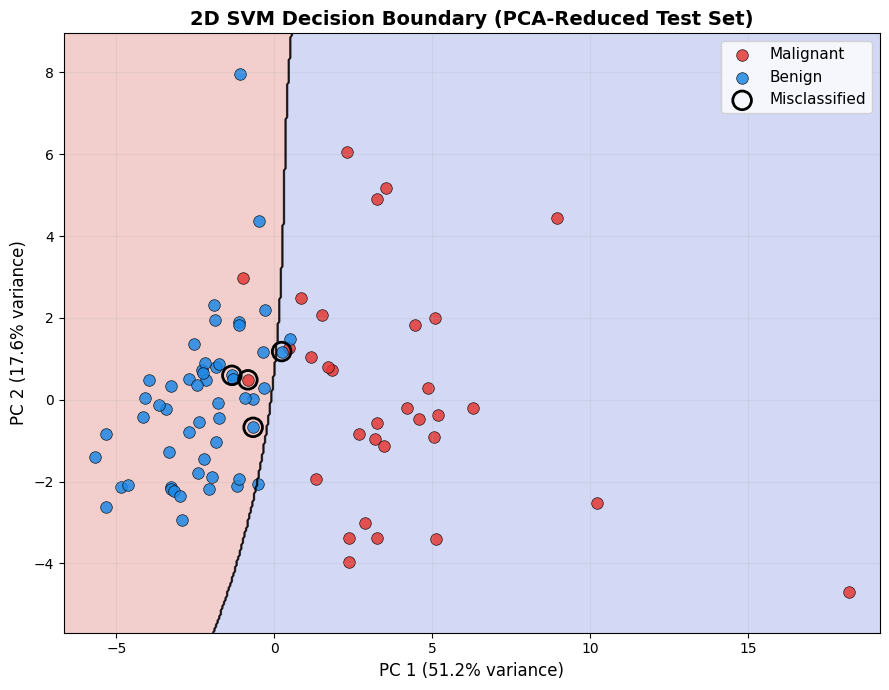

2D Classification Plot saved as 'classification_2d_plot.png'
SVM WORKFLOW — COMPLETE SUMMARY
  Dataset          : Breast Cancer Wisconsin (569 samples, 30 features)
  Train / Val / Test Split: 70% / 15% / 15%
  Preprocessing    : StandardScaler, median imputation
  Tuning Method    : GridSearchCV (5-Fold Stratified CV)
  Best Params      : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
  Best CV Accuracy : 97.49%
  Final Test Accuracy  : 95.35%
  Final Test Precision : 0.9808
  Final Test Recall    : 0.9444
  Final Test F1-Score  : 0.9623
  Final Test AUC-ROC   : 0.9954

 Saved Outputs:
 confusion_matrix.png
 evaluation_metrics.png
 roc_curve.png
 sample_predictions.png
 classification_2d_plot.png

 SVM Classification Workflow COMPLETE.


In [19]:
pca = PCA(n_components=2, random_state=42)
X_test_2d = pca.fit_transform(X_test_scaled)
h = 0.05
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X_train_2d = pca.transform(X_train_scaled)
svm_2d = SVC(kernel=best_params.get('kernel', 'rbf'),
             C=best_params.get('C', 1),
             gamma=best_params.get('gamma', 'scale'),
             probability=True, random_state=42)
svm_2d.fit(X_train_2d, y_train)

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
ax.contour(xx, yy, Z, colors='k', linewidths=0.8, alpha=0.4)

colors_map = {0: '#E53935', 1: '#1E88E5'}
labels_map  = {0: 'Malignant', 1: 'Benign'}

for cls in [0, 1]:
    mask = y_test.values == cls
    ax.scatter(
        X_test_2d[mask, 0], X_test_2d[mask, 1],
        c=colors_map[cls],
        label=labels_map[cls],
        edgecolors='k',
        linewidths=0.5,
        s=70,
        alpha=0.85
    )
misclassified = y_test.values != y_test_pred
ax.scatter(
    X_test_2d[misclassified, 0], X_test_2d[misclassified, 1],
    s=180, facecolors='none', edgecolors='black',
    linewidths=2.0, label='Misclassified', zorder=5
)
variance_explained = pca.explained_variance_ratio_
ax.set_xlabel(f'PC 1 ({variance_explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC 2 ({variance_explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('2D SVM Decision Boundary (PCA-Reduced Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('classification_2d_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("2D Classification Plot saved as 'classification_2d_plot.png'")
print("SVM WORKFLOW — COMPLETE SUMMARY")
print(f"  Dataset          : Breast Cancer Wisconsin ({df.shape[0]} samples, {df.shape[1]-1} features)")
print(f"  Train / Val / Test Split: 70% / 15% / 15%")
print(f"  Preprocessing    : StandardScaler, median imputation")
print(f"  Tuning Method    : GridSearchCV (5-Fold Stratified CV)")
print(f"  Best Params      : {best_params}")
print(f"  Best CV Accuracy : {best_score*100:.2f}%")
print(f"  Final Test Accuracy  : {accuracy*100:.2f}%")
print(f"  Final Test Precision : {precision:.4f}")
print(f"  Final Test Recall    : {recall:.4f}")
print(f"  Final Test F1-Score  : {f1:.4f}")
print(f"  Final Test AUC-ROC   : {auc:.4f}")
print("\n Saved Outputs:")
print(" confusion_matrix.png")
print(" evaluation_metrics.png")
print(" roc_curve.png")
print(" sample_predictions.png")
print(" classification_2d_plot.png")
print("\n SVM Classification Workflow COMPLETE.")
